# CIFAR-10 Image Classification with Custom CNN

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset
import numpy as np
import matplotlib.pyplot as plt

# Set device for training (GPU if available, else CPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


## TASK **1**

We will load the CIFAR-10 dataset and filter it to include only the 'airplane', 'automobile', and 'ship' classes. A custom transformation is applied to normalize the images.

In [ ]:
# Define transformations for the dataset
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)) # Normalize pixel values to [-1, 1]
])

# Load CIFAR-10 training and test datasets
train_dataset_full = datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
test_dataset_full = datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)

# Define the target classes (now all 10 CIFAR-10 classes)
cifar10_classes = train_dataset_full.classes
target_classes = cifar10_classes # Use all 10 classes

print(f"Target classes: {target_classes}")

# For the full CIFAR-10 dataset, labels are already 0-9, so no special mapping is needed.
# We will use the full datasets directly.
train_dataset = train_dataset_full
test_dataset = test_dataset_full

print(f"Number of training samples: {len(train_dataset)}")
print(f"Number of testing samples: {len(test_dataset)}")

100%|██████████| 170M/170M [00:02<00:00, 76.7MB/s]


Target classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
Number of training samples: 50000
Number of testing samples: 10000


## 2. Define the CNN Architecture

We will define a simple Convolutional Neural Network (CNN) based on the provided specifications:
- Convolution layer: 16 filters, 3x3 kernel, padding='same'
- ReLU activation
- Max Pooling layer: 2x2 kernel, stride=2
- Fully connected layer: 3 class output
- Softmax output layer (implicitly handled by `CrossEntropyLoss`)

In [ ]:
class SimpleCNN(nn.Module):
    def __init__(self, num_classes=10):
        super(SimpleCNN, self).__init__()
        # Input: 3x32x32 (RGB image)

        # First Convolutional Block
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=16, kernel_size=3, padding='same')
        self.bn1 = nn.BatchNorm2d(16) # Batch Norm
        self.relu1 = nn.ReLU() # Added ReLU
        # Max Pooling layer: 2x2 kernel, stride=2
        # Output after pool1: 16x16x16
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)

        # Second Convolutional Block
        # Output after conv2: 32x16x16
        self.conv2 = nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, padding='same')
        self.bn2 = nn.BatchNorm2d(32)
        self.relu2 = nn.ReLU()
        # Max Pooling layer: 2x2 kernel, stride=2
        # Output after pool2: 32x8x8
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)

        # Fully connected layer
        # After two pooling layers. 32 channels.
        self.fc = nn.Linear(32 * 8 * 8, num_classes)

    def forward(self, x):
        # First block
        x = self.relu1(self.bn1(self.conv1(x)))
        x = self.pool1(x)

        # Second block
        x = self.relu2(self.bn2(self.conv2(x)))
        x = self.pool2(x)

        # Flatten the output for the fully connected layer
        x = x.view(-1, 32 * 8 * 8)
        x = self.fc(x)
        return x
# Instantiate the model and move it to the device
model = SimpleCNN(num_classes=len(cifar10_classes)).to(device)
print(model)

SimpleCNN(
  (conv1): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=same)
  (bn1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu1): ReLU()
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=same)
  (bn2): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu2): ReLU()
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc): Linear(in_features=2048, out_features=10, bias=True)
)


## 3. Training the CNN Classifier

We will train the CNN using the Adam optimizer, Cross Entropy Loss function, a training batch size of 64, and train for 10 epochs.

In [ ]:
# Hyperparameters
BATCH_SIZE = 64
LEARNING_RATE = 0.001
EPOCHS = 10

# Data loaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

# Loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

# Training loop
def train_model(model, train_loader, criterion, optimizer, epochs):
    model.train() # Set the model to training mode
    history = {'loss': []}

    for epoch in range(epochs):
        running_loss = 0.0
        for i, (inputs, labels) in enumerate(train_loader):
            inputs, labels = inputs.to(device), labels.to(device)

            # Zero the parameter gradients
            optimizer.zero_grad()

            # Forward pass
            outputs = model(inputs)
            loss = criterion(outputs, labels)

            # Backward pass and optimize
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

        epoch_loss = running_loss / len(train_loader)
        history['loss'].append(epoch_loss)
        print(f"Epoch {epoch+1}/{epochs}, Loss: {epoch_loss:.4f}")
    print("Finished Training")
    return history

training_history = train_model(model, train_loader, criterion, optimizer, EPOCHS)

Epoch 1/10, Loss: 1.2996
Epoch 2/10, Loss: 0.9937
Epoch 3/10, Loss: 0.9052
Epoch 4/10, Loss: 0.8471
Epoch 5/10, Loss: 0.8013
Epoch 6/10, Loss: 0.7650
Epoch 7/10, Loss: 0.7375
Epoch 8/10, Loss: 0.7130
Epoch 9/10, Loss: 0.6915
Epoch 10/10, Loss: 0.6765
Finished Training


## 5. Training Loss Curve

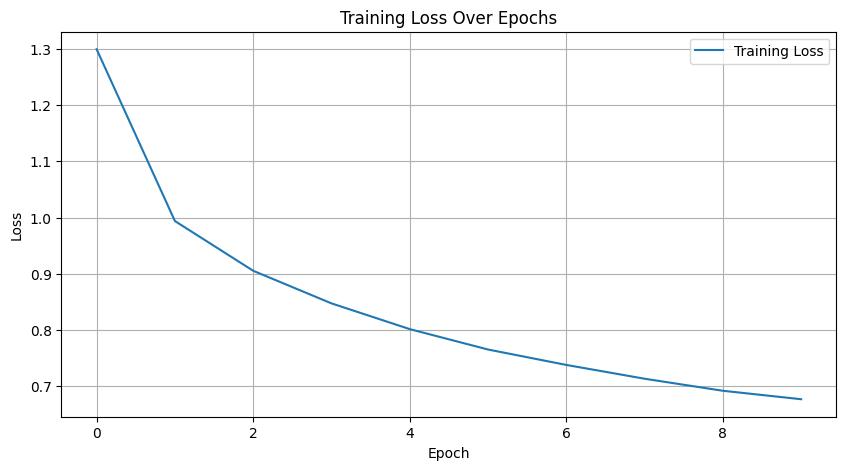

In [ ]:
# Plotting the training loss curve
plt.figure(figsize=(10, 5))
plt.plot(training_history['loss'], label='Training Loss')
plt.title('Training Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

## 6. Confusion Matrix

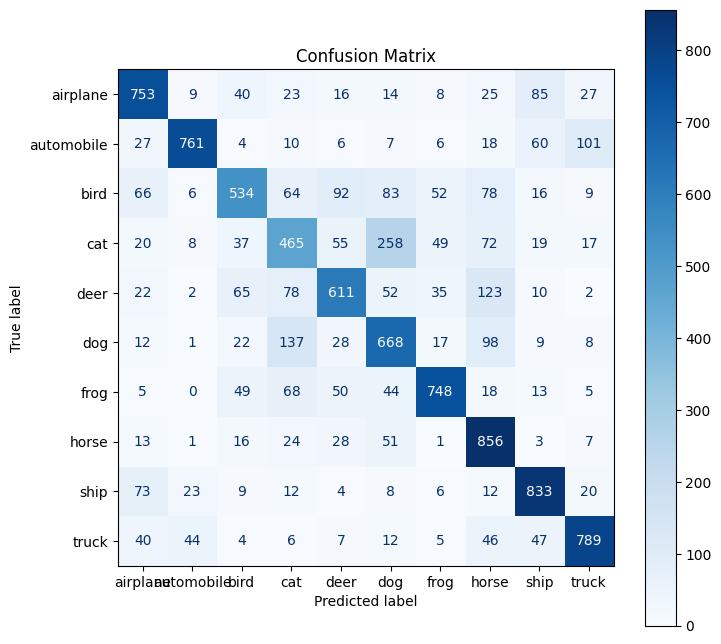

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

def generate_confusion_matrix(model, test_loader, target_classes):
    model.eval()
    all_labels = []
    all_predictions = []
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, predicted = torch.max(outputs.data, 1)
            all_labels.extend(labels.cpu().numpy())
            all_predictions.extend(predicted.cpu().numpy())

    cm = confusion_matrix(all_labels, all_predictions)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=target_classes)

    fig, ax = plt.subplots(figsize=(8, 8))
    disp.plot(cmap=plt.cm.Blues, ax=ax)
    plt.title('Confusion Matrix')
    plt.show()

generate_confusion_matrix(model, test_loader, cifar10_classes) # Updated to use cifar10_classes

## 4. Evaluate the Classifier

Finally, we will evaluate the trained CNN classifier on the test images to assess its performance.

In [ ]:
# Evaluation loop
def evaluate_model(model, test_loader):
    model.eval() # Set the model to evaluation mode
    correct = 0
    total = 0
    with torch.no_grad(): # Disable gradient calculation during evaluation
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    accuracy = 100 * correct / total
    print(f"Accuracy of the network on the {total} test images: {accuracy:.2f}%")

evaluate_model(model, test_loader)

Accuracy of the network on the 10000 test images: 70.18%
